In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

# Attempt to find the file in the user's Google Drive
file_path = "/content/drive/MyDrive/Data for projects/superstore.csv"

# Reading data
try:
    df = pd.read_csv(file_path, encoding='latin1')
    print("LOADING DATASET....", '\n', '\n', df.head())
    print("LOADING DATASET....", '\n', '\n', df.tail())
    print("SHAPE OF DATASET", '\n', '\n', df.shape)
    print('\n', '\n', df.info())
    print('\n', '\n', df.describe())

    # Missing and Duplicate values
    print(df.isnull().sum())
    print(df.duplicated().sum())

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please make sure the file 'superstore.csv' is in the root of your Google Drive.")

LOADING DATASET.... 
 
    Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category

In [26]:
# Type casting
df['Category'] = pd.Categorical(df['Category'])
df['Sub-Category'] = pd.Categorical(df['Sub-Category'])
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
# create the following derived columns to unlock deeper insights:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Day'] = df['Order Date'].dt.day
df['Weekday'] = df['Order Date'].dt.day_name()
df['Ship_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# Key business metric
df['Profit Margin (%)'] = round((df['Profit'] / df['Sales']) * 100, 2)

df['Ship_Duration'].describe()
df['Profit Margin (%)'].describe()
df[df['Profit'] < 0].head()




,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Day,Weekday,Ship_Duration,Profit Margin (%)
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,October,11,Sunday,7,-40.00
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,68.8100,5,0.80,-123.8580,2015,November,22,Sunday,4,-180.00
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,2.5440,3,0.80,-3.8160,2015,November,22,Sunday,4,-150.00
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,71.3720,2,0.30,-1.0196,2017,July,16,Sunday,2,-1.43
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,3083.4300,7,0.50,-1665.0522,2015,September,17,Thursday,4,-54.00


1) Create target and quick class check

In [27]:
# 1. Target
df['Profitable'] = (df['Profit'] > 0).astype(int)
print(df['Profitable'].value_counts(normalize=True))
# show absolute counts too
print(df['Profitable'].value_counts())


Profitable
1    0.806284
0    0.193716
Name: proportion, dtype: float64
Profitable
1    8058
0    1936
Name: count, dtype: int64


class balance : 80/20

2) Train/test split
(Time split)

---



   To simulate real-world, do a time split (train on earlier years, test on

latest year).



In [28]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
# Extract Month and Weekday names
df['Month'] = df['Order Date'].dt.month_name()
df['Weekday'] = df['Order Date'].dt.day_name()

train_df = df[df['Year'] < 2017].copy()
test_df  = df[df['Year'] == 2017].copy()

# Define the list of columns to be used as features and for derived features
feature_cols = [
    'Sales', 'Quantity', 'Discount', 'Profit Margin (%)', 'Ship_Duration',
    'Region', 'Segment', 'Category', 'Sub-Category', 'Ship Mode',
    'Month', 'Weekday', 'Profit' # Keep 'Profit' for potential future derived features if needed
]

X_train = train_df[feature_cols].copy()
y_train = train_df['Profitable']
X_test  = test_df[feature_cols].copy()
y_test  = test_df['Profitable']


### Feature Engineering

To enhance our model's performance, we've engineered several new features:

*   **`Log_Sales`**: A log-transformed version of 'Sales' (`np.log1p(Sales)`). This helps to stabilize the variance and reduce skewness in the 'Sales' distribution, making it more suitable for models that assume normal distribution.
*   **`High_Discount`**: A binary indicator (`1` or `0`) that flags orders with a 'Discount' greater than or equal to 0.3. This highlights aggressive discounting strategies that might impact profitability.
*   **`Month_Num`**: A numerical representation of the 'Month' from the 'Order Date' (1 for January, 12 for December). This allows the model to capture monthly seasonality.
*   **`Weekday_Num`**: A numerical representation of the 'Weekday' from the 'Order Date' (1 for Monday, 7 for Sunday). This captures weekly patterns in orders.
*   **`SubCat_ProfRate`**: This is a target-encoded feature based on the 'Sub-Category'. It represents the average 'Profitable' rate for each 'Sub-Category' calculated from the training data. For new 'Sub-Category' values in the test set, it's filled with the overall mean 'Profitable' rate from the training data to prevent data leakage.

In [29]:
import numpy as np
import pandas as pd

# basic derived (if not present)
X_train = X_train.copy()
X_test  = X_test.copy()

for df_ in [X_train, X_test]:
    df_['Log_Sales'] = np.log1p(df_['Sales'])
    df_['High_Discount'] = (df_['Discount'] >= 0.3).astype(int)
    # numeric month from Month name
    month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
    df_['Month_Num'] = df_['Month'].map(month_map)
    # day of week numeric
    dow_map = {'Monday':1,'Tuesday':2,'Wednesday':3,'Thursday':4,'Friday':5,'Saturday':6,'Sunday':7}
    df_['Weekday_Num'] = df_['Weekday'].map(dow_map)
    # profit margin already exists
    # flag categories (option: keep Category and Sub-Category as categorical for encoder)


In [30]:
# target encoding example (using training data only)
means_sub = X_train.join(y_train).groupby('Sub-Category')['Profitable'].mean()
X_train['SubCat_ProfRate'] = X_train['Sub-Category'].map(means_sub)
X_test['SubCat_ProfRate']  = X_test['Sub-Category'].map(means_sub).fillna(means_sub.mean())

print(means_sub)


Sub-Category
Accessories    0.872000
Appliances     0.867110
Art            1.000000
Binders        0.601173
Bookcases      0.526316
Chairs         0.604215
Copiers        1.000000
Envelopes      1.000000
Fasteners      0.901961
Furnishings    0.806552
Labels         1.000000
Machines       0.597561
Paper          1.000000
Phones         0.852101
Storage        0.779570
Supplies       0.816794
Tables         0.362791
Name: Profitable, dtype: float64


/tmp/ipython-input-2112518396.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_sub = X_train.join(y_train).groupby('Sub-Category')['Profitable'].mean()


4) Build robust preprocessing pipeline (ColumnTransformer)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# define features
numeric_features = ['Sales','Quantity','Discount','Profit Margin (%)','Ship_Duration','Log_Sales','Month_Num','Weekday_Num']
# keep only numeric that exist; adjust accordingly

categorical_features = ['Region','Segment','Category','Sub-Category','Ship Mode']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.96      0.99      0.97       639
           1       1.00      0.99      0.99      2673

    accuracy                           0.99      3312
   macro avg       0.98      0.99      0.98      3312
weighted avg       0.99      0.99      0.99      3312

ROC-AUC: 0.9997740109025103


In [33]:
from sklearn.ensemble import RandomForestClassifier
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       639
           1       1.00      1.00      1.00      2673

    accuracy                           1.00      3312
   macro avg       1.00      1.00      1.00      3312
weighted avg       1.00      1.00      1.00      3312

ROC-AUC: 1.0


In [34]:
import xgboost as xgb
from xgboost import XGBClassifier

pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(n_estimators=200, max_depth=6, use_label_encoder=False, eval_metric='logloss', random_state=42))
])
pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:04:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       639
           1       1.00      1.00      1.00      2673

    accuracy                           1.00      3312
   macro avg       1.00      1.00      1.00      3312
weighted avg       1.00      1.00      1.00      3312

ROC-AUC: 1.0


In [35]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'clf__n_estimators': [100,200,400],
    'clf__max_depth': [6,10,14],
    'clf__min_samples_split': [2,5,10]
}

rs = RandomizedSearchCV(pipe_rf, param_dist, n_iter=8, scoring='roc_auc', cv=5, n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
print("Best params:", rs.best_params_)
best_rf = rs.best_estimator_
y_proba_best = best_rf.predict_proba(X_test)[:,1]
print("ROC-AUC (best):", roc_auc_score(y_test, y_proba_best))


Best params: {'clf__n_estimators': 400, 'clf__min_samples_split': 10, 'clf__max_depth': 6}
ROC-AUC (best): 1.0


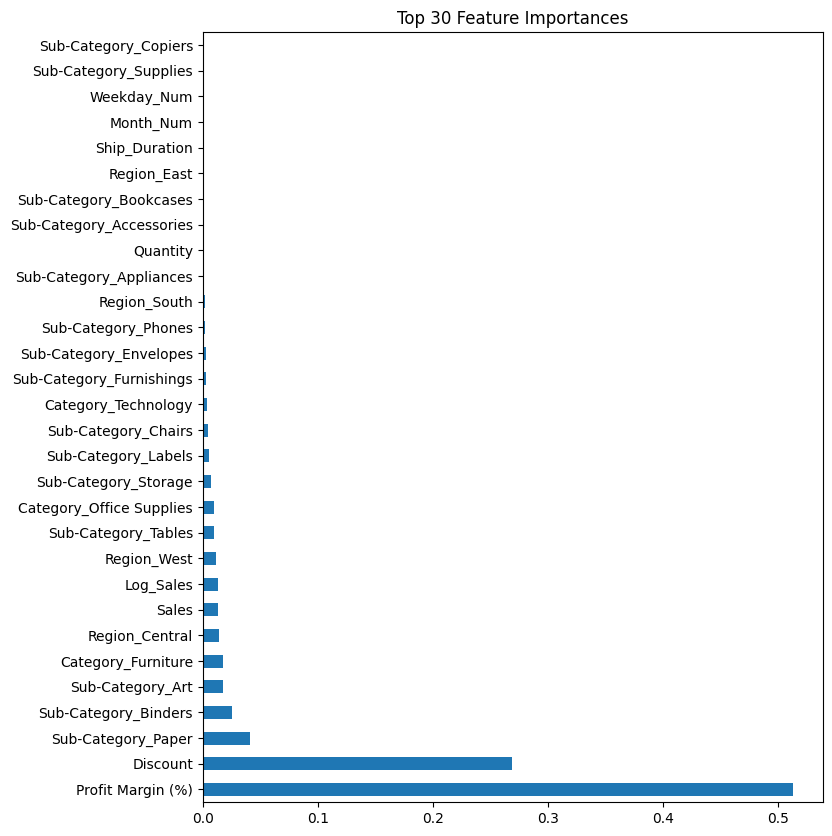

In [36]:
# get feature names
cat_features = rs.best_estimator_.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
num_features = numeric_features
feature_names = list(num_features) + list(cat_features)

importances = rs.best_estimator_.named_steps['clf'].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(30)
fi.plot(kind='barh', figsize=(8,10))
plt.title("Top 30 Feature Importances")
plt.show()


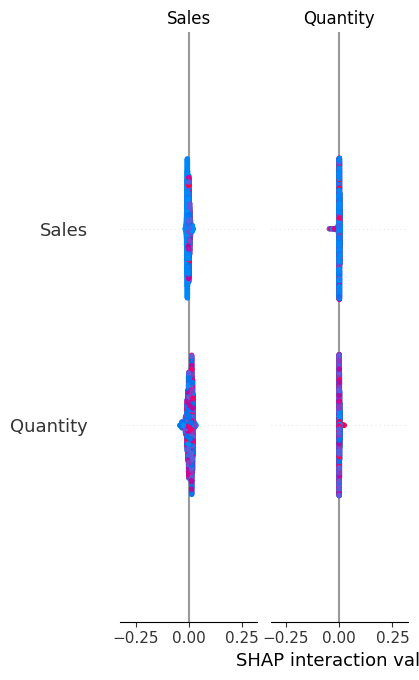

In [37]:
import shap
# use TreeExplainer for tree models
model = rs.best_estimator_.named_steps['clf']
# Need matrix after preprocessing:
X_test_trans = rs.best_estimator_.named_steps['preprocessor'].transform(X_test)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_trans)
# summary plot
shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names, plot_type="bar")


In [38]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_proba_best)
# choose threshold where recall >= 0.8 or where F1 maximizes
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1_scores)
best_thr = thr[best_idx]
print("Best threshold (F1):", best_thr, "F1:", f1_scores[best_idx])


Best threshold (F1): 0.693987390752055 F1: 0.9999999995


In [39]:
# Minimal pipeline + RF quick run
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
pipe = Pipeline([
    ('preproc', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1))
])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:,1]
print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       639
           1       1.00      1.00      1.00      2673

    accuracy                           1.00      3312
   macro avg       1.00      1.00      1.00      3312
weighted avg       1.00      1.00      1.00      3312

ROC AUC: 1.0
